In [1]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

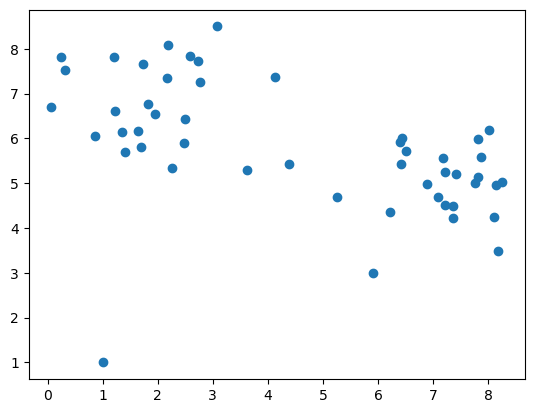

In [2]:
# First, let's make our toy dataset

X = np.ones((50,2))
X[0:25,0] = np.random.randn(25) + 2
X[24:-1,0] = np.random.randn(25) + 7
X[0:25,1] = np.random.randn(25) + 7
X[24:-1,1] = np.random.randn(25) + 5

plt.scatter(X[:,0],X[:,1])

Let's see what PCA does to this dataset:

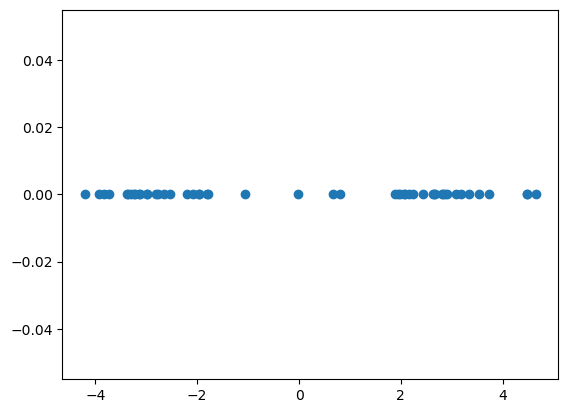

In [3]:
#create the model
pca = PCA(n_components=1)
#fit and transform
X_red = pca.fit_transform(X)
#plot
plt.scatter(X_red, np.zeros(50))

Perhaps it would be more enlightening to show these side by side with a bit of color!

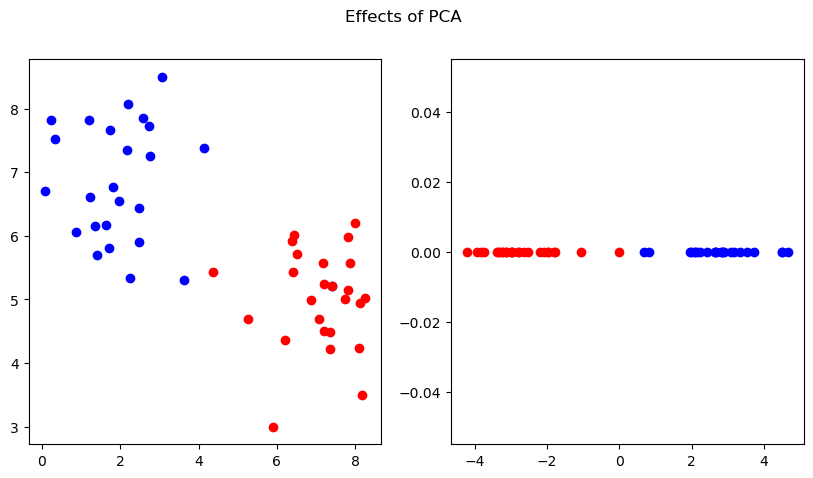

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
fig.suptitle('Effects of PCA')
ax1.scatter(X[0:25,0],X[0:25,1], color = 'blue')
ax1.scatter(X[24:-1,0],X[24:-1,1], color = 'red')
ax2.scatter(X_red[0:25], np.zeros(25), color = 'blue')
ax2.scatter(X_red[24:-1], np.zeros(25), color = 'red')

PCA is projecting our data onto a subspace in a way that maximizes the variance. In this case, it's looking for a line along which the data is most spread out:

Text(0.5, 1.0, "Here's such a line")

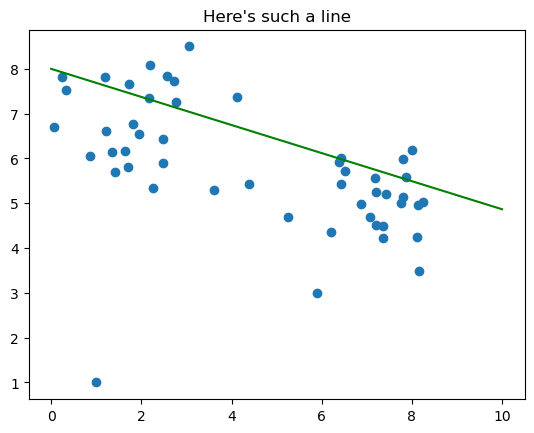

In [5]:
x = np.linspace(0,10,100)
slope = pca.components_[0,1]/pca.components_[0,0]

y = slope*x + 8

plt.scatter(X[:,0],X[:,1])
plt.plot(x,y, color = 'green')
plt.title("Here's such a line")

But, we can do it the ol' fashioned way too! PCA takes the covariance matrix $C$ of $X^T$ and uses the SVD to find a lower-rank approximation of $C$. $C$, as it turns out, is positive semidefinite, which gives us a lot of nice properties. One such property is that, in the decomposition $C=U\Sigma V^T$, $U$ is equal to $V$!

In our example, we go from a rank $2$ covariance matrix to a rank 1 approximation of it given by $\sigma_1 v_1 v_1^T$, where $\sigma_1$ is the largest eigenvalue of $C$ and $v_1$ is its corresponding eigenvector.

We project in the direction of $v_1$:

In [6]:
# create covariance matrix
C = np.cov(X.T)

# find SVD
U,S,V = np.linalg.svd(C)

# v_1 is the first eigenvector:
v = V[:,0]

In [7]:
# first we make a projection matrix: straightforward when projecting onto
# the span of a unit vector!

P= np.outer(v,v)

X_red2 = X.dot(P.T)

Let's see what this has done to our data:

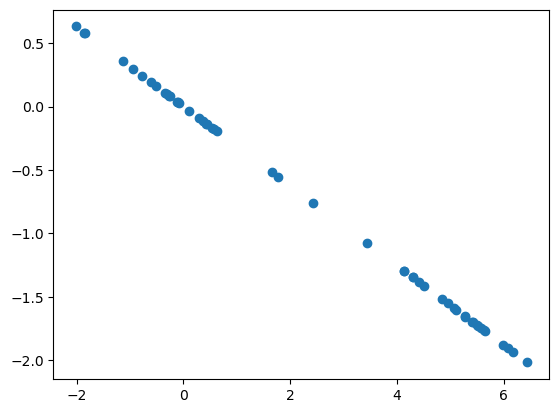

In [8]:
plt.scatter(X_red2[:,0], X_red2[:,1])

Is this what we wanted? Maybe. To be extra certain, let's rotate this and compare to the output of sklearn's PCA function:

In [9]:
# first we make a rotation matrix R that rotates v to (1,0):

R = np.array([[v[0], v[1]],
             [-v[1], v[0]]])
#check it does what we want:
R.dot(v)

array([1., 0.])

In [10]:
# rotate the data
X_red2 = X_red2.dot(R.T)

Moment of truth! Let's make our comparison:

(-0.5, 0.5)

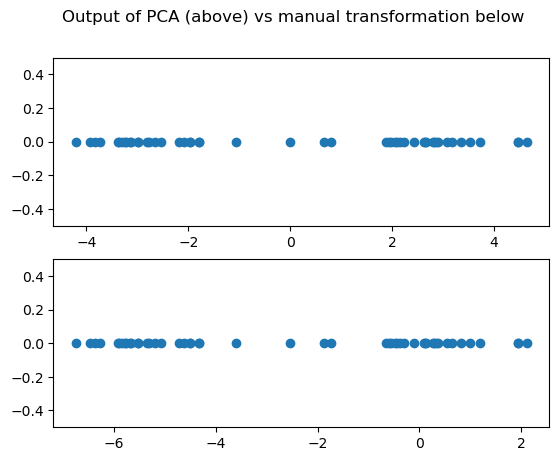

In [11]:
fig, axs = plt.subplots(2)
fig.suptitle('Output of PCA (above) vs manual transformation below')
axs[0].scatter(X_red, np.zeros(50))
axs[1].scatter(X_red2[:,0], X_red2[:,1])
axs[0].set_ylim([-0.5,0.5])
axs[1].set_ylim([-0.5,0.5])

I'd say this passes the eye test- PCA does a little more to prepare the data (like scaling and centering) but these two graphs look pretty similar. 